Large cells segmented QC does not look great, need to check the original segmentation to see if it is better just in case

In [1]:
import anndata as ad
import os
import random
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq
import scipy.sparse as sp

from datetime import datetime
from matplotlib import gridspec

/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/envs/rk_spatial_min/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/envs/rk_spatial_min/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
adata = sc.read("/oak/stanford/scg/lab_mpsnyder/johnck/Projects/RK/Spatial/Ranger_procd/ALS2_SD01915_BG__largecells_reseg_20251215_064234_job49421202_4/outs/ALS2_SD01915_BG__largecells_reseg_20251215_064234_job49421202_4_scanpy.h5ad")

In [4]:
## Perform basic QC analysis á la Squidpy
sc.pp.calculate_qc_metrics(adata, percent_top = (10, 20, 50, 150), inplace = True)

# Calculate percentage of control probes and control codewords
cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.01906406501822147
Negative decoding count % : 0.004977477726600487


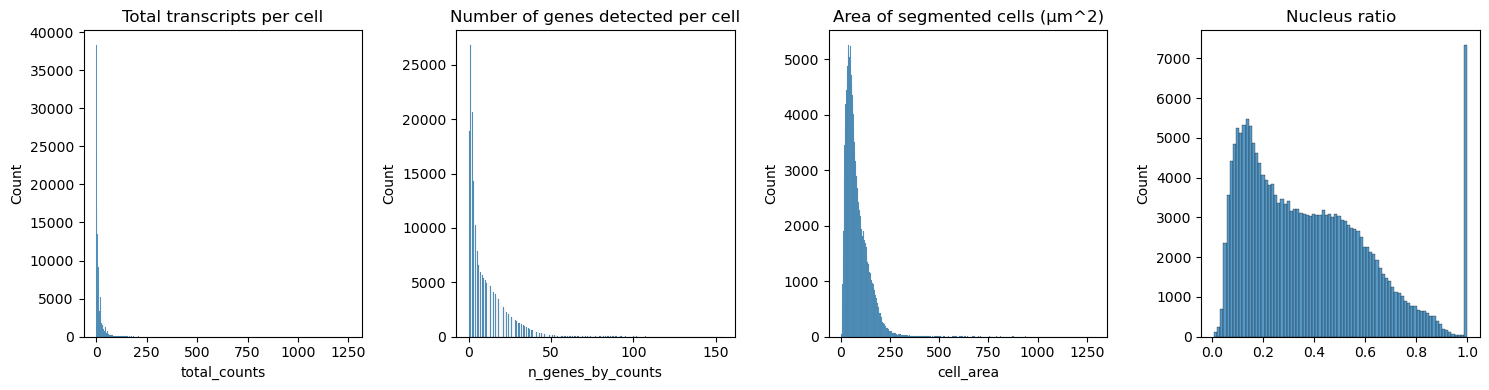

In [7]:
# Plot distribution of total transcripts per cell, unique transcripts per cell,
# area of segmented cells and the ratio of nuclei area to their cells
fig, axs = plt.subplots(1, 4, figsize = (15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata.obs["total_counts"],
    kde=False,
    ax=axs[0],
)
#axs[0].set_ylim(0, 1850)  # Set ylim to 1850

axs[1].set_title("Number of genes detected per cell")
sns.histplot(
    adata.obs["n_genes_by_counts"],
    kde=False,
    ax=axs[1],
)
#axs[1].set_ylim(0, 1850)  # Set ylim to 1850

axs[2].set_title("Area of segmented cells (μm^2)")
sns.histplot(
    adata.obs["cell_area"],
    kde=False,
    ax=axs[2],
)
#axs[2].set_ylim(0, 1850)  # Set ylim to 1850

axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata.obs["nucleus_area"] / adata.obs["cell_area"],
    kde=False,
    ax=axs[3],
)
#axs[3].set_ylim(0, 2850)  # Set ylim to 1850

plt.tight_layout()

# Get the directory of the current notebook
notebook_dir = os.getcwd()

# Define the output file path in the same directory as the notebook
output_file = os.path.join(notebook_dir, "summary_histograms_ALS2_SD01915_BG.png")

# Save the figure
plt.savefig(output_file, dpi=300)
plt.show()

<Axes: title={'center': 'Number of cells per gene'}, xlabel='n_cells_by_counts', ylabel='Count'>

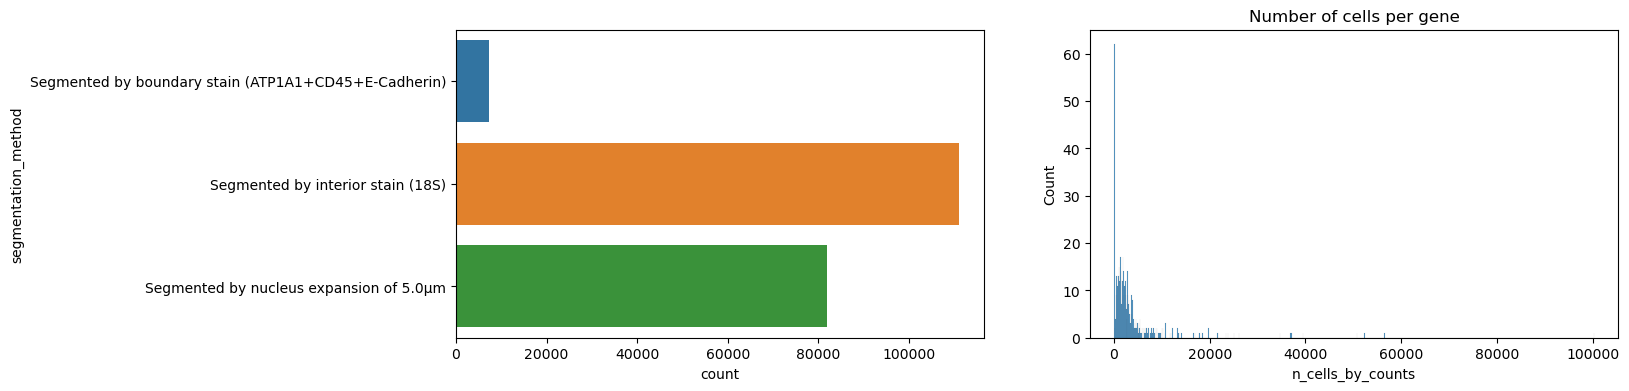

In [8]:
# Plot distribution of segmentation method
fig, axs = plt.subplots(1, 2, figsize = (15, 4))
sns.countplot(
            data=adata.obs,
            y='segmentation_method',
            hue='segmentation_method',
            ax = axs[0])
axs[1].set_title("Number of cells per gene")
sns.histplot(
    adata.var["n_cells_by_counts"],
    kde=False,
    bins = 1000,
    ax=axs[1]
)

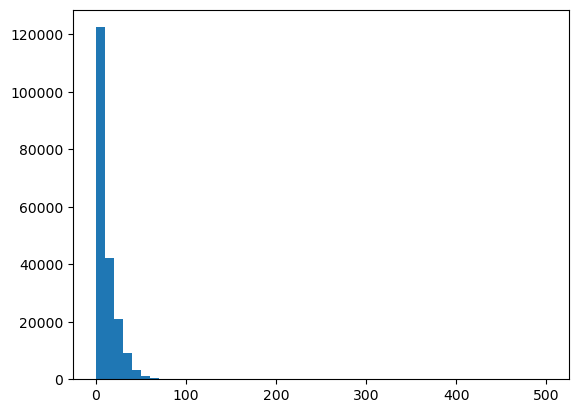

In [9]:
# Checking necrosis by number of genes per cell
n, bins, patches = plt.hist(adata.obs["n_genes_by_counts"], bins=50, range=(0,500)) # Change the upper bound of the range to where you think makes sense.   
min_index = n.argmin()
necrosis_cutoff_genes = (bins[min_index] + bins[min_index+1])/2

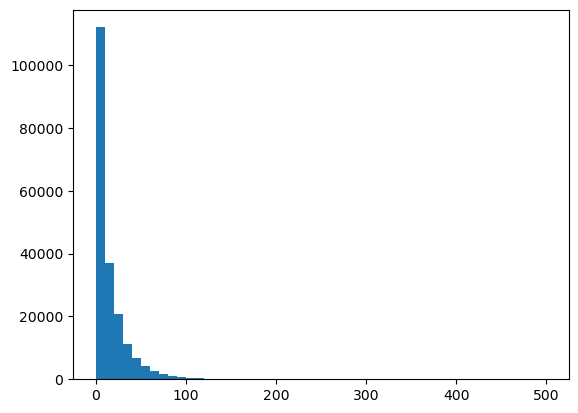

In [10]:
# Checking necrosis by transript count per cell
n, bins, patches = plt.hist(adata.obs["total_counts"], bins=50, range=(0,500)) # Change the upper bound of the range to where you think makes sense.   
min_index = n.argmin()
necrosis_cutoff_transcripts = (bins[min_index] + bins[min_index+1])/2

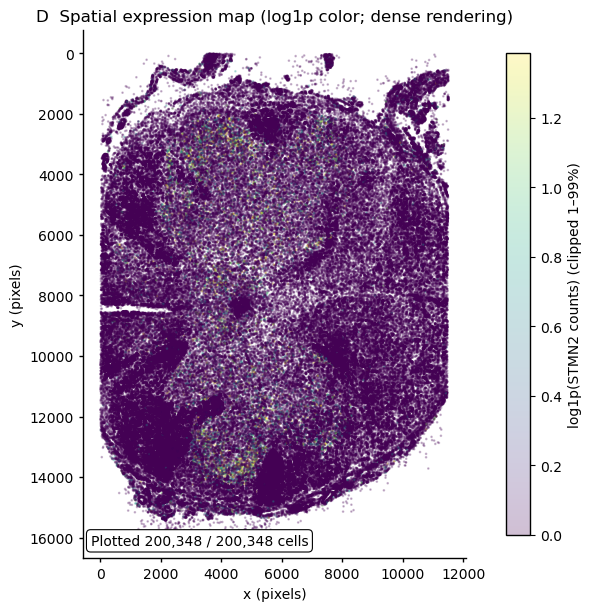

In [12]:
# Dense spatial expression map for a single gene (Nature-style, despined)
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
gene_name = "STMN2"
max_points_spatial = 250_000  # set to None to plot all cells (may be slow)
point_size = 0.8
alpha_pts = 0.25
rasterize_spatial = True
clip_percentiles = (1, 99)

# -----------------------------
# Helper: simple despine (no seaborn)
# -----------------------------
def despine(ax, left=True, bottom=True, top=False, right=False, linewidth=1.0):
    ax.spines["top"].set_visible(top)
    ax.spines["right"].set_visible(right)
    ax.spines["left"].set_visible(left)
    ax.spines["bottom"].set_visible(bottom)
    for side in ["left", "bottom", "top", "right"]:
        ax.spines[side].set_linewidth(linewidth)
    ax.tick_params(width=linewidth)

# -----------------------------
# Extract gene expression
# -----------------------------
var_upper = adata.var_names.str.upper()
hits = np.where(var_upper == gene_name.upper())[0]
if len(hits) == 0:
    close = [g for g in adata.var_names if gene_name.upper() in g.upper()]
    raise ValueError(f"{gene_name} not found in adata.var_names. Closest matches: {close[:20]}")
gene = adata.var_names[hits[0]]

x = adata[:, gene].X
x = x.toarray().ravel() if hasattr(x, "toarray") else np.asarray(x).ravel()
n = x.size

# -----------------------------
# Spatial coordinates + subsampling
# -----------------------------
if "spatial" not in adata.obsm or adata.obsm["spatial"] is None:
    raise ValueError("No spatial coordinates found in adata.obsm['spatial'].")

xy = np.asarray(adata.obsm["spatial"])
if xy.ndim != 2 or xy.shape[1] < 2:
    raise ValueError("adata.obsm['spatial'] must be an array of shape (n_obs, >=2).")

idx = np.arange(n)
if (max_points_spatial is not None) and (n > max_points_spatial):
    rng = np.random.default_rng(0)
    idx = rng.choice(idx, size=max_points_spatial, replace=False)

xy_sub = xy[idx, :2]
x_sub = x[idx]
logx_sub = np.log1p(x_sub)

# Percentile clipping for contrast
vmin, vmax = np.percentile(logx_sub, clip_percentiles)

# -----------------------------
# Plot Panel D
# -----------------------------
fig, axD = plt.subplots(figsize=(6.5, 6.0), constrained_layout=True)

sca = axD.scatter(
    xy_sub[:, 0], xy_sub[:, 1],
    c=logx_sub,
    s=point_size,
    alpha=alpha_pts,
    vmin=vmin,
    vmax=vmax,
    rasterized=rasterize_spatial
)

axD.set_title("D  Spatial expression map (log1p color; dense rendering)")
axD.set_xlabel("x (pixels)")
axD.set_ylabel("y (pixels)")
axD.set_aspect("equal", adjustable="box")
axD.invert_yaxis()
axD.tick_params(length=3)
despine(axD)

cbar = fig.colorbar(sca, ax=axD, fraction=0.046, pad=0.04)
cbar.set_label(f"log1p({gene} counts) (clipped {clip_percentiles[0]}–{clip_percentiles[1]}%)")
cbar.outline.set_linewidth(1.0)

axD.text(
    0.02, 0.02,
    f"Plotted {len(idx):,} / {n:,} cells",
    transform=axD.transAxes,
    va="bottom", ha="left",
    bbox=dict(boxstyle="round,pad=0.3", linewidth=0.8, facecolor="white")
)

plt.show()
